# 01. 선형회귀모델
## 1-1 단일선형회귀

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

Epoch [100/99], Loss:  3.6078
Epoch [200/199], Loss:  3.5807
Epoch [300/299], Loss:  3.5564
Epoch [400/399], Loss:  3.5344
Epoch [500/499], Loss:  3.5145
Epoch [600/599], Loss:  3.4965
Epoch [700/699], Loss:  3.4802
Epoch [800/799], Loss:  3.4654
Epoch [900/899], Loss:  3.4520
Epoch [1000/999], Loss:  3.4399


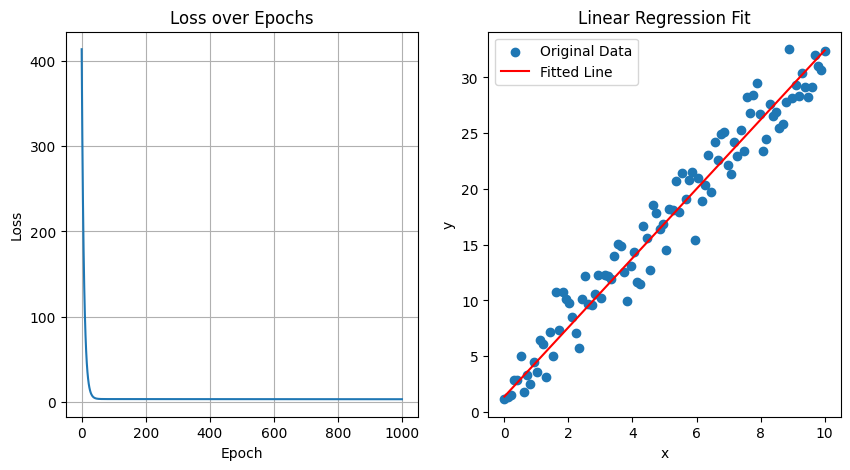

Model Parameters: 
linear.weight: tensor([[3.1034]])
linear.bias: tensor([1.3874])


In [4]:
# 1. 데이터 생성
x = torch.linspace(0,10,100).view(-1,1) #입력 데이터
y = 3 * x + 2 + torch.randn(100, 1) * 2

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
    def __init__(self,):
        super().__init__()
        self.linear = nn.Linear(1,1) #입력 1개, 출력 1개
        
    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

# 3. 손실 함수, 옵티마이저 정의
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.001) #확률적 경사 하강법

# 4. 가중치 업데이트
epochs = 1000 #학습 반복 횟수
losses = []

for epoch in range(epochs):
    optimizer.zero_grad() #기울기 초기화
    outputs = model(x) # 예측값 계산
    loss = criterion(outputs, y) # 손실 계산
    loss.backward() #역전파
    optimizer.step() #가중치 업데이트

    losses.append(loss.item())

    #100번에 한번씩 로그 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epoch}], Loss: {loss.item(): .4f}")

# 5. 결과 시각화
plt.figure(figsize=(10,5))

#손실 감소 그래프
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

#데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x.numpy(), y.numpy(), label="Original Data")
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label= "Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

print("Model Parameters: ")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

### 훈련 데이터, 평가 데이터 분리

Epoch [100/99], Loss:  5.7070
Epoch [200/199], Loss:  5.5151
Epoch [300/299], Loss:  5.3416
Epoch [400/399], Loss:  5.1844
Epoch [500/499], Loss:  5.0421
Epoch [600/599], Loss:  4.9133
Epoch [700/699], Loss:  4.7966
Epoch [800/799], Loss:  4.6910
Epoch [900/899], Loss:  4.5953
Epoch [1000/999], Loss:  4.5087
최종 Test Loss:  2.6206


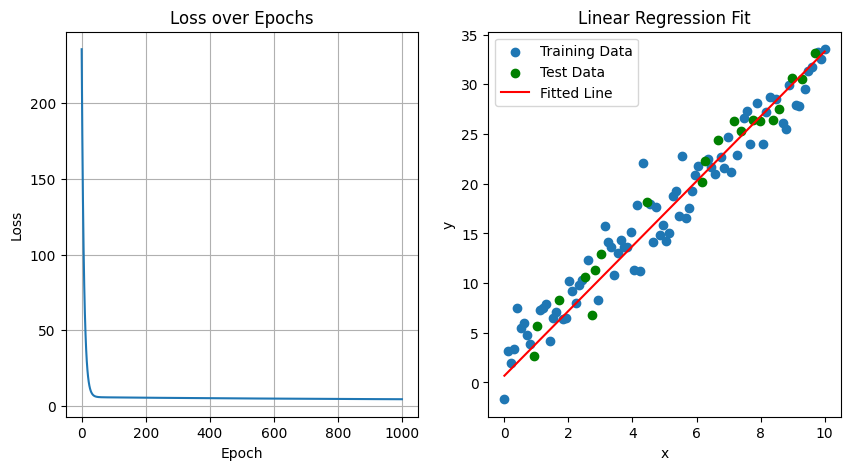

In [5]:
# 1. 데이터 생성
x = torch.linspace(0,10,100).view(-1,1) #입력 데이터
y = 3 * x + 2 + torch.randn(100, 1) * 2

#Train / Test set 분리(8:2로 분리 )
num_train = int(len(x) * 0.8)
indices = torch.randperm(len(x))
train_idx, test_idx = indices[:num_train], indices[num_train:]

x_train, y_trian = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
    def __init__(self,):
        super().__init__()
        self.linear = nn.Linear(1,1) #입력 1개, 출력 1개
        
    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

# 3. 손실 함수, 옵티마이저 정의
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.001) #확률적 경사 하강법

# 4. 가중치 업데이트
epochs = 1000 #학습 반복 횟수
losses = []

for epoch in range(epochs):
    optimizer.zero_grad() #기울기 초기화
    outputs = model(x) # 예측값 계산
    loss = criterion(outputs, y) # 손실 계산
    loss.backward() #역전파
    optimizer.step() #가중치 업데이트

    losses.append(loss.item())

    #100번에 한번씩 로그 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epoch}], Loss: {loss.item(): .4f}")


# 5. 테스트 데이터 평가
with torch.no_grad():
    test_output = model(x_test)
    test_loss = criterion(test_output, y_test)
print(f"최종 Test Loss: {test_loss.item(): .4f}")


# 5. 결과 시각화
plt.figure(figsize=(10,5))

#손실 감소 그래프
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

#데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x_train.numpy(), y_trian.numpy(), label="Training Data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Test Data", color ="g")
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label= "Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

# print("Model Parameters: ")
# for name, param in model.named_parameters():
#     print(f"{name}: {param.data}")

Epoch [100/99], Loss:  2.2778
Epoch [200/199], Loss:  2.2249
Epoch [300/299], Loss:  2.2217
Epoch [400/399], Loss:  2.2191
Epoch [500/499], Loss:  2.2166
Epoch [600/599], Loss:  2.2143
Epoch [700/699], Loss:  2.2120
Epoch [800/799], Loss:  2.2099
Epoch [900/899], Loss:  2.2078
Epoch [1000/999], Loss:  2.2057


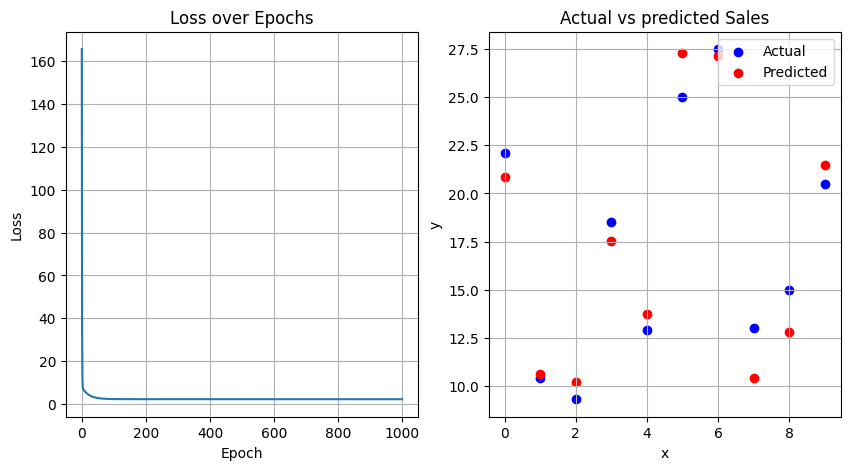

Model Parameters: 
linear.weight: tensor([[ 0.2018,  0.5288, -0.0854]])
linear.bias: tensor([0.1290])


In [6]:
# 실습 - 다중 선형 회귀 구현

# 1. 데이터 입출력 정의
x = torch.tensor([[50.0, 25.0, 30.0],
                  [10.0, 20.0, 25.0],
                  [5.0, 22.0, 30.0],
                  [30.0, 26.0, 28.0],
                  [40.0, 15.0, 28.0],
                  [60.0, 35.0, 40.0],
                  [70.0, 30.0, 35.0],
                  [20.0, 15.0, 20.0],
                  [25.0, 18.0, 22.0],
                  [45.0, 28.0, 30.0]], dtype=torch.float32)

y = torch.tensor([[22.1], [10.4], [9.3], [18.5], [12.9], 
                  [25.0], [27.5], [13.0], [15.0], [20.5]], dtype=torch.float32)


# 2. 모델 정의
class MultipleLinearRegression(nn.Module):
    def __init__(self,):
        super(MultipleLinearRegression,self).__init__()
        self.linear = nn.Linear(3,1) #입력 3개, 출력 1개
        
    def forward(self, x):
        return self.linear(x)

model = MultipleLinearRegression()

# 3. 손실 함수, 옵티마이저 정의
criterion = nn.MSELoss() # 평균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.0001) #확률적 경사 하강법

# 4. 가중치 업데이트(학습)
epochs = 1000 #학습 반복 횟수
losses = []

for epoch in range(epochs):
    optimizer.zero_grad() #기울기 초기화
    outputs = model(x) # 예측값 계산
    loss = criterion(outputs, y) # 손실 계산
    loss.backward() #역전파
    optimizer.step() #가중치 업데이트

    losses.append(loss.item())

    #100번에 한번씩 로그 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epoch}], Loss: {loss.item(): .4f}")


# 5. 결과 시각화
plt.figure(figsize=(10,5))

#손실 감소 그래프
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
predicted = model(x).detach().numpy()
actual = y.numpy()

plt.subplot(1, 2, 2)
plt.scatter(range(len(actual)), actual, label ="Actual", color="b")
plt.scatter(range(len(predicted)), predicted, label ="Predicted", color="r")
plt.title("Actual vs predicted Sales")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

print("Model Parameters: ")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")